In [1]:
import cv2, numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


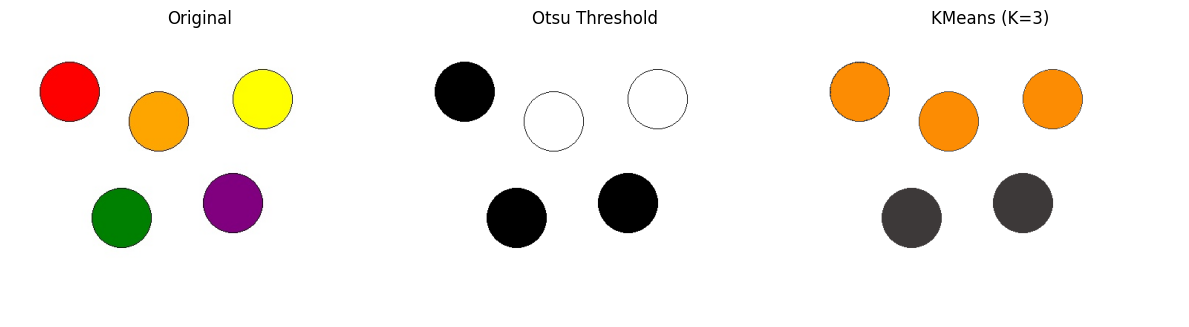

In [2]:
img = cv2.imread("/content/drive/MyDrive/Computer Vision/dataset/fruits.jpg")
assert img is not None, "fruits.jpg tidak ditemukan."
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Threshold Otsu
otsu,th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
# K-Means clustering (BGR)
Z = img.reshape((-1,3)).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 3
compactness, labels, centers = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
seg = centers[labels.flatten()].reshape(img.shape).astype(np.uint8)
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(th, cmap='gray'); plt.title("Otsu Threshold"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(cv2.cvtColor(seg, cv2.COLOR_BGR2RGB)); plt.title("KMeans (K=3)"); plt.axis("off")
plt.tight_layout(); plt.show()


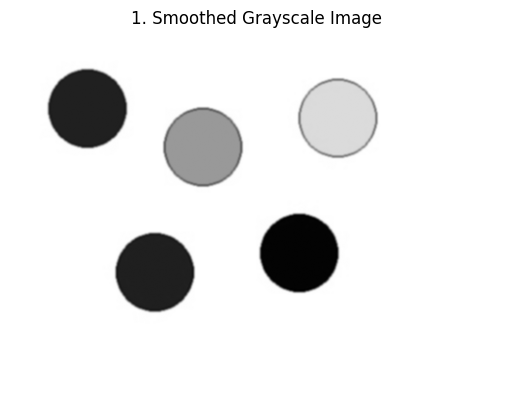

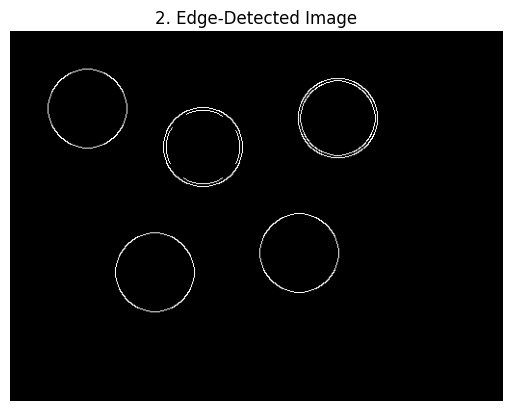

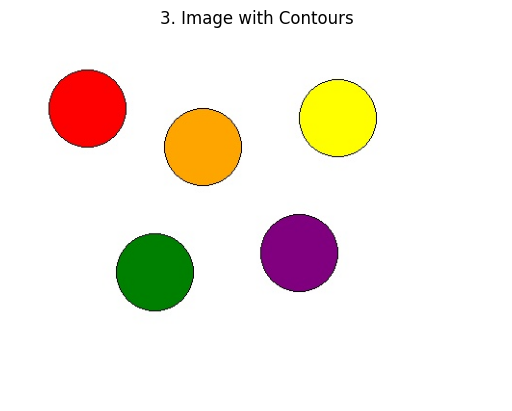

Coins in the image:  5


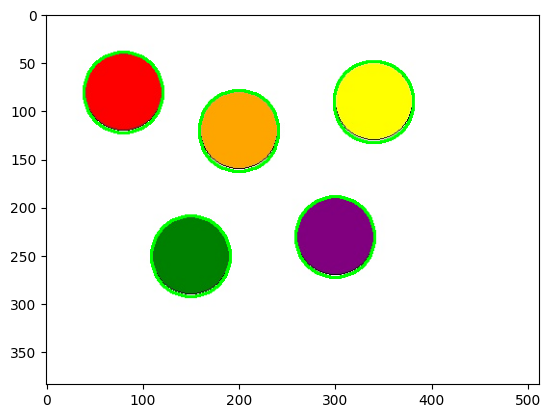

In [5]:
 # 1. Preprocessing: (Load image and Convert to grayscale)
image = cv2.imread(" /fruits.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray');
# 2. Smoothing: Apply Gaussian smoothing to the grayscale image to reduce noise ( Use the cv2.GaussianBlur() function for smoothin
blur = cv2.GaussianBlur(gray, (5,5), 0)
plt.imshow(blur, cmap='gray')
plt.title('1. Smoothed Grayscale Image')
plt.axis('off')
plt.show()
# 3. Thresholding: Apply binary thresholding to the smoothed image to create a binary image (Use the cv2.threshold() function for
# 4. Edge Detection: Apply Canny edge detection to the thresholded image (Use the cv2.Canny() function for edge detection.)
canny = cv2.Canny(blur, 30, 150)
plt.imshow(canny, cmap='gray')
plt.title('2. Edge-Detected Image')
plt.axis('off')
plt.show()
dilated = cv2.dilate(canny, (1,1), iterations = 2)
plt.imshow(dilated, cmap='gray')
# 5. Contour Detection: Find contours in the edge-detected image (using cv2.findContours() function)
contours, _ = cv2.findContours(canny.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Create a copy of the original image to draw contours on
contour_image = image.copy()
plt.imshow(cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB))
plt.title('3. Image with Contours')
plt.axis('off')
plt.show()
# 6. Coin Counting:
(cnt, heirarchy) = cv2.findContours(dilated.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
cv2.drawContours(rgb, cnt, -1, (0,255,0), 2)
plt.imshow(rgb)
print('Coins in the image: ', len(cnt))
plt.show()


Coins in the image:  4


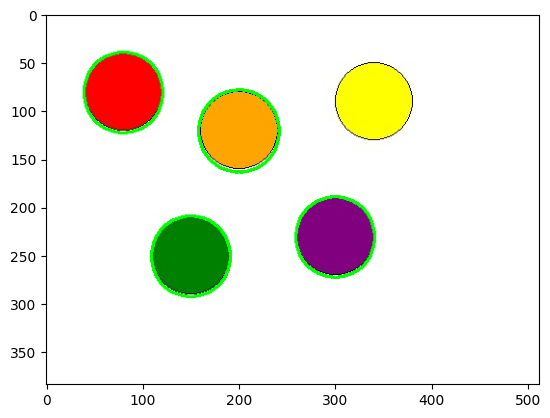

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
image = cv2.imread("/content/drive/MyDrive/Computer Vision/dataset/fruits.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray');
blur = cv2.GaussianBlur(gray, (15,15), 0)
plt.imshow(blur, cmap='gray')
canny = cv2.Canny(blur, 30, 150)
plt.imshow(canny, cmap='gray')
dilated = cv2.dilate(canny, (1,1), iterations = 2)
plt.imshow(dilated, cmap='gray')
# Find contours in the edge-detected image
contours, _ = cv2.findContours(canny.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Create a copy of the original image to draw contours on
contour_image = image.copy()
(cnt, heirarchy) = cv2.findContours(dilated.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
cv2.drawContours(rgb, cnt, -1, (0,255,0), 2)
plt.imshow(rgb)
print('Coins in the image: ', len(cnt))
plt.show()
